In [13]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  name : str
  age: str
  result : str
  

In [14]:
def first_node(state : AgentState) -> AgentState:
  """First node in multinode graph"""
  
  state['result'] = f"Hi, {state['name']}"
  return state

def second_node(state : AgentState) -> AgentState:
  """Second node in multinode graph"""
  
  state['result'] = state['result'] + f" you are {state['age']} years old!"
  return state


In [15]:
grpah_builder = StateGraph(AgentState)

grpah_builder.add_node("firstNode" , first_node)
grpah_builder.add_node("secondNode", second_node)

grpah_builder.add_edge(START, "firstNode")
grpah_builder.add_edge("firstNode", "secondNode")
grpah_builder.add_edge("secondNode" , END)

graph = grpah_builder.compile()

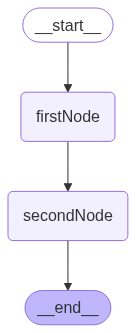

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
answer = graph.invoke({"name" : "Dishant" , "age" : "21"})
print(answer)

{'name': 'Dishant', 'age': '21', 'result': 'Hi, Dishant you are 21 years old!'}
